Irish Power Markets Historical Analysis

In [38]:
import sqlite3
import pandas as pd

# 1. Connect directly to your local database asset
conn = sqlite3.connect('irish_grid.db')

# 2. Read the entire historical database straight into Pandas
irish_grid_df = pd.read_sql_query("SELECT * FROM market_actuals", conn, index_col='timestamp')

# 3. Convert the index back to a proper datetime format so your charts work perfectly
irish_grid_df.index = pd.to_datetime(irish_grid_df.index, utc=True)

conn.close()

print(f"✅ Data Asset Loaded Completely Offline!")
print(f"Total historical records in DB: {len(irish_grid_df)} hours.")
irish_grid_df.tail(3)

✅ Data Asset Loaded Completely Offline!
Total historical records in DB: 17232 hours.


,price_eur_mwh,total_supply_mw,actual_wind_mw,actual_solar_mw,wind_speed_100m,temperature_2m,net_gb_flow_mw,transmission_capacity_snsp,transmission_capacity_utilization_pct,gen_gas_mw,gen_coal_mw,gen_oil_mw,gen_hydro_mw,gen_peat_mw,gen_biowaste_mw
timestamp,,,,,,,,,,,,,,,
2026-07-03 05:00:00+00:00,156.945,0.000,NaN,0.0,18.4,13.8,NaN,0.000,NaN,NaN,None,NaN,0.000,0.0,NaN
2026-07-03 06:00:00+00:00,213.445,39.576,NaN,0.0,20.5,14.0,NaN,29.682,NaN,NaN,None,NaN,39.576,0.0,NaN
2026-07-03 07:00:00+00:00,211.205,NaN,NaN,0.0,24.8,14.3,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN


Temperature Vs Load/Supply

Below you will see I-SEM, and Temperature data for the last two year period. 

We will first look at the relationship between temperature and Load. 

The comfort level seems to be between the 15 - 25 celcius range, where demand is at its lowest. This is likely because minimial airconditioning or heating is required for businesses and homes to operate comfortably. 

As can be seen from the below, the moment the temperature drops below 15 celcius we can notice a steady increase in demand. This is likely due to Irelands heating being heavily dependant on electric storage heaters and electric heat pumps illustrating thermal eslasticity.

We can also see that the load starts flattening around the -5 - 0 celcius and 0 - 5 celcius buckets at about 3200 - 3300 MW. This is likely due to reaching peak winter demand profile.



The Price Curve

When we look at the load from the 10 - 15 celcius bucket to the 5- 10 celcius bucket, we can see that the increase is very slight. in comparison to the price increase from 115 MW/H to 126MW/H. Moreover when we look at the temperature bucket below zero (-5 - 0 celcius bucket) we see the price increase exponentialy to the upside.

This is likely happening because of the merit order stack. Its probable that wind solar and gas are fully maxxed out to that 3300MW winter peak profile level and the TSO has to call on more expensive power plants to satisfy demand along with potentially importing more supply through the interconnector pipelines from GB which is also under a similar pressure.

The Summer Anomaly

In the 20 - 25 celcius bracket we can notice an anomaly. The load is at its lowest however we can observe a spike int the electricity day ahead market to 126 MW/H. This is likely due to 2 factors and we saw this happen just a couple of weeks ago in June 2026. 

The first is interconnector arbitrage. When Ireland suffers a heatwave so do the rest of Europe. Dropping river levels and increase in river temperatures massively effect the efficiency of both hydro and nuclear power plants. (Nuclear needs huge amounts of water to cool the reactors). This will mean that GB and the rest of Europe will need to turn on more expensive generators to satisfy demand imbalance from the nuclear and hydro plants shutting down and also import power from elsewhere. Despite Ireland having a low load, electricity gets pulled from Ireland through the interconnectors (power flows from low price to high price) which also effects prices in the Irish markets.

Gas power plants also become less efficient in hot weather meaning that more fuel is needed to generate the same MW of electricity which raises the floor price of electricity. 



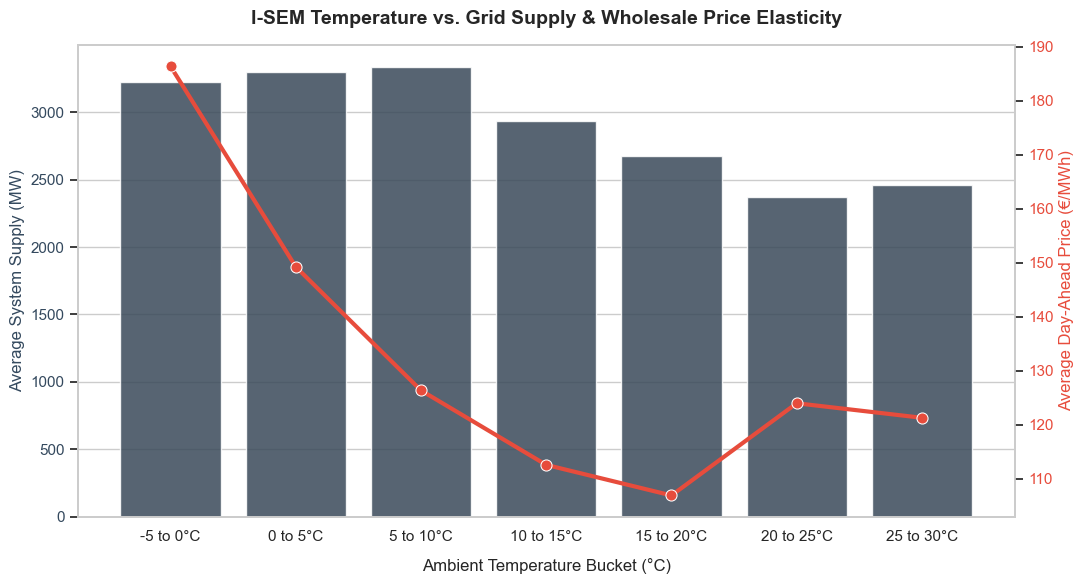


             avg_supply_mw  avg_price_eur  hours_observed
temp_bucket                                              
-5 to 0°C          3223.25         186.35             112
0 to 5°C           3298.41         149.24            1541
5 to 10°C          3331.75         126.35            4650
10 to 15°C         2935.45         112.57            6559
15 to 20°C         2675.61         106.91            3070
20 to 25°C         2374.28         123.97             322
25 to 30°C         2457.01         121.28              33

💡 COMMERCIAL INSIGHT:
As weather drops from the [5-10°C] bucket down into the freezing [0-5°C] bucket,
the grid adds an average of **-6.67 MW** of supply per 1°C drop.


In [39]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure inline plotting works inside your notebook
%matplotlib inline

# 1. Connect to your database and extract data
db_path = 'irish_grid.db'
conn = sqlite3.connect(db_path)
query = """
    SELECT temperature_2m, total_supply_mw, price_eur_mwh 
    FROM market_actuals
    WHERE temperature_2m IS NOT NULL AND total_supply_mw IS NOT NULL
"""
df = pd.read_sql_query(query, conn)
conn.close()

# 2. Mathematically calculate 5°C Buckets
df['bucket_lower'] = (np.floor(df['temperature_2m'] / 5) * 5).astype(int)
df['bucket_upper'] = df['bucket_lower'] + 5
df['temp_bucket'] = df['bucket_lower'].astype(str) + " to " + df['bucket_upper'].astype(str) + "°C"

# 3. Aggregate data by bucket (keep bucket_lower for clean chronological sorting)
elasticity_curve = df.groupby(['bucket_lower', 'temp_bucket']).agg(
    avg_supply_mw=('total_supply_mw', 'mean'),
    avg_price_eur=('price_eur_mwh', 'mean'),
    hours_observed=('total_supply_mw', 'count')
).reset_index()

# Sort by temperature lower bound so the plot reads logically from cold to warm
elasticity_curve = elasticity_curve.sort_values('bucket_lower')

# -------------------------------------------------------------------
# 📊 VISUALIZATION ENGINE (Plotting the Elasticity & Price Curves)
# -------------------------------------------------------------------
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(11, 6))

# Primary Axis: System Supply (Bar Chart)
sns.barplot(
    data=elasticity_curve, 
    x='temp_bucket', 
    y='avg_supply_mw', 
    ax=ax1, 
    color='#34495e', 
    alpha=0.85
)
ax1.set_title('I-SEM Temperature vs. Grid Supply & Wholesale Price Elasticity', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Ambient Temperature Bucket (°C)', fontsize=12, labelpad=10)
ax1.set_ylabel('Average System Supply (MW)', fontsize=12, color='#34495e')
ax1.tick_params(axis='y', labelcolor='#34495e')

# Secondary Axis: Wholesale Price (Line Chart overlay to capture non-linear spikes)
ax2 = ax1.twinx()
sns.lineplot(
    data=elasticity_curve, 
    x=np.arange(len(elasticity_curve)), # Align perfectly with categorical bar positions
    y='avg_price_eur', 
    ax=ax2, 
    color='#e74c3c', 
    linewidth=3, 
    marker='o', 
    markersize=8
)
ax2.set_ylabel('Average Day-Ahead Price (€/MWh)', fontsize=12, color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')
ax2.grid(False) # Turn off secondary grid lines to avoid cluttering

plt.tight_layout()
plt.show()

# 4. Print the raw data summary right below the chart
print("\n" + "="*70)
# Use bucket_lower to set the indexing cleanly for printing
print(elasticity_curve.set_index('temp_bucket')[['avg_supply_mw', 'avg_price_eur', 'hours_observed']].round(2))
print("="*70)

# 5. Extract and print the commercial risk metric
try:
    elasticity_indexed = elasticity_curve.set_index('temp_bucket')
    cold_5_10 = elasticity_indexed.loc["5 to 10°C", "avg_supply_mw"]
    freezing_0_5 = elasticity_indexed.loc["0 to 5°C", "avg_supply_mw"]
    
    mw_per_degree = (freezing_0_5 - cold_5_10) / 5.0
    print(f"\n💡 COMMERCIAL INSIGHT:")
    print(f"As weather drops from the [5-10°C] bucket down into the freezing [0-5°C] bucket,")
    print(f"the grid adds an average of **{mw_per_degree:.2f} MW** of supply per 1°C drop.")
except KeyError:
    print("\n💡 Note: Insufficient data points in the extreme 0-5°C or 5-10°C ranges to print cold-slope metrics.")

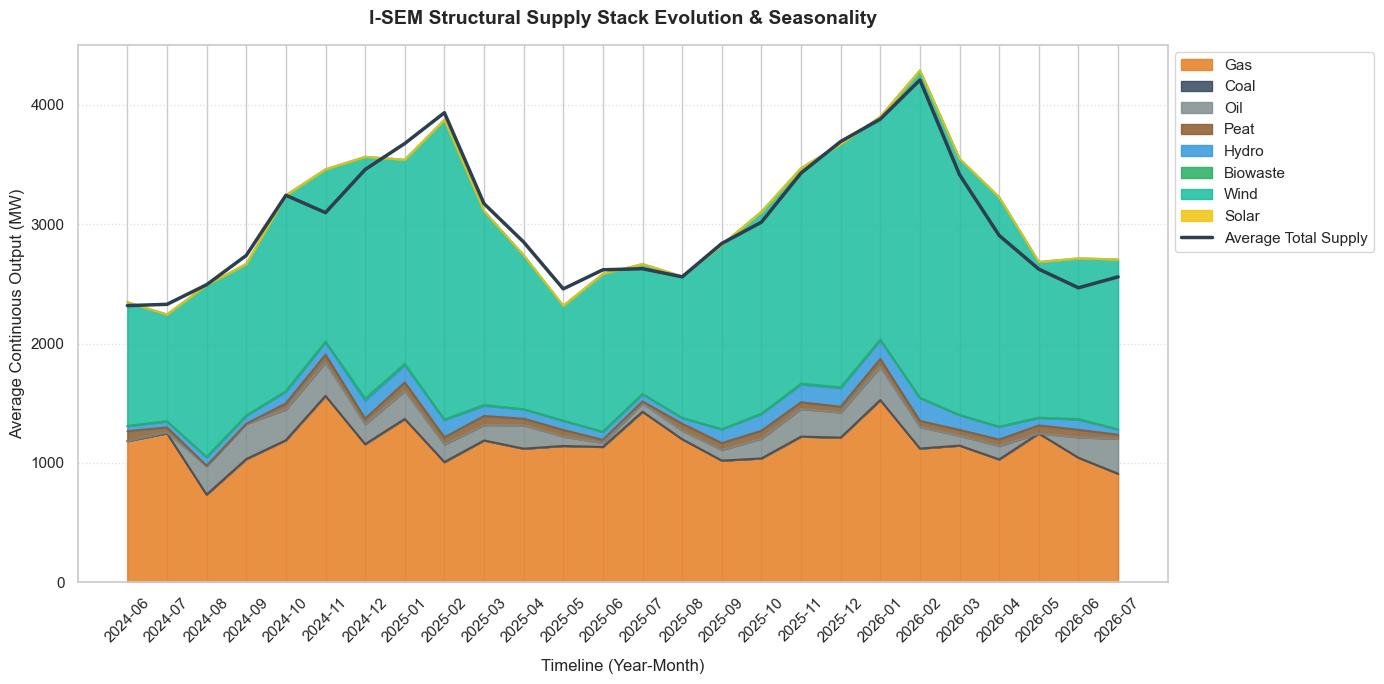


📅 MONTHLY HISTORICAL GENERATION STACK PROFILES (AVERAGE MW)
            avg_total_supply_mw  gen_gas_mw  gen_peat_mw  gen_biowaste_mw  \
year_month                                                                  
2024-06                 2318.02     1183.14        83.07             0.00   
2024-07                 2328.99     1248.39        41.64             2.74   
2024-08                 2493.42      734.24         1.77             1.22   
2024-09                 2738.60     1031.90         0.56             1.60   
2024-10                 3242.76     1190.02        52.51             5.35   
2024-11                 3097.25     1561.72        65.86             5.85   
2024-12                 3458.64     1156.84        48.69            17.14   
2025-01                 3676.62     1368.27        71.48             9.67   
2025-02                 3934.76     1007.25        61.58             4.17   
2025-03                 3172.70     1188.09        76.27             6.94   
2025-04        

In [35]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Ensure inline plotting works inside your notebook
%matplotlib inline

# 1. Connect to your database and extract the entire operational asset matrix
db_path = 'irish_grid.db'
conn = sqlite3.connect(db_path)
query = """
    SELECT 
        timestamp, 
        total_supply_mw,
        gen_gas_mw, 
        gen_coal_mw, 
        gen_oil_mw, 
        gen_peat_mw, 
        gen_hydro_mw, 
        gen_biowaste_mw, 
        actual_wind_mw,
        actual_solar_mw
    FROM market_actuals
"""
df = pd.read_sql_query(query, conn, parse_dates=['timestamp'])
conn.close()

# 2. Extract year-month strings for structural grouping (e.g., "2024-01")
df['year_month'] = df['timestamp'].dt.to_period('M').astype(str)

# 3. Aggregate metrics by Year-Month
generation_columns = [
    'gen_gas_mw', 'gen_coal_mw', 'gen_oil_mw', 'gen_peat_mw', 
    'gen_hydro_mw', 'gen_biowaste_mw', 'actual_wind_mw', 'actual_solar_mw'
]

monthly_trends = df.groupby('year_month').agg(
    avg_total_supply_mw=('total_supply_mw', 'mean'),
    **{f"{col}": (col, 'mean') for col in generation_columns}
).reset_index()

# Sort chronologically
monthly_trends = monthly_trends.sort_values('year_month')

# Clean up column names for the legend presentation
rename_dict = {col: col.replace('gen_', '').replace('_mw', '').replace('actual_', '').title() for col in generation_columns}
plot_df = monthly_trends.rename(columns=rename_dict).set_index('year_month')

# -------------------------------------------------------------------
# 📊 VISUALIZATION ENGINE (Using Pandas Wrapper to bypass type bugs)
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 7))

# Define an institutional-grade color palette for the individual fuel types
colors = [
    '#e67e22', # Gas (Orange)
    '#34495e', # Coal (Dark Grey)
    '#7f8c8d', # Oil (Light Grey)
    '#8b5a2b', # Peat (Brown)
    '#3498db', # Hydro (Blue)
    '#27ae60', # Biowaste (Green)
    '#1abc9c', # Wind (Teal)
    '#f1c40f'  # Solar (Yellow)
]

# Cleaned column list matching the renamed versions
cleaned_columns = list(rename_dict.values())

# 🟢 THE FIX: Pandas .plot(kind='area') compiles data internally, completely avoiding the TypeError
plot_df[cleaned_columns].plot(
    kind='area', 
    ax=ax, 
    stacked=True, 
    color=colors, 
    alpha=0.85, 
    legend=True
)

# Overlay the Total Supply line over the area plot
ax.plot(
    range(len(plot_df)), # Align perfectly with categorical string index locations
    plot_df['avg_total_supply_mw'], 
    color='#2c3e50', 
    linestyle='-', 
    linewidth=2.5, 
    label='Average Total Supply'
)

# Chart styling and labeling
ax.set_title('I-SEM Structural Supply Stack Evolution & Seasonality', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Timeline (Year-Month)', fontsize=12, labelpad=10)
ax.set_ylabel('Average Continuous Output (MW)', fontsize=12)
plt.xticks(range(len(plot_df)), plot_df.index, rotation=45)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=True)
ax.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 4. Print out the raw historical dataset summary underneath the chart
print("\n" + "="*95)
print("📅 MONTHLY HISTORICAL GENERATION STACK PROFILES (AVERAGE MW)")
print("="*95)
print(monthly_trends.set_index('year_month')[['avg_total_supply_mw', 'gen_gas_mw', 'gen_peat_mw', 'gen_biowaste_mw', 'actual_wind_mw']].round(2))
print("="*95)

/var/folders/31/74nn24mn2hq7byy_hff937wm0000gn/T/ipykernel_67054/1869594644.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/31/74nn24mn2hq7byy_hff937wm0000gn/T/ipykernel_67054/1869594644.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


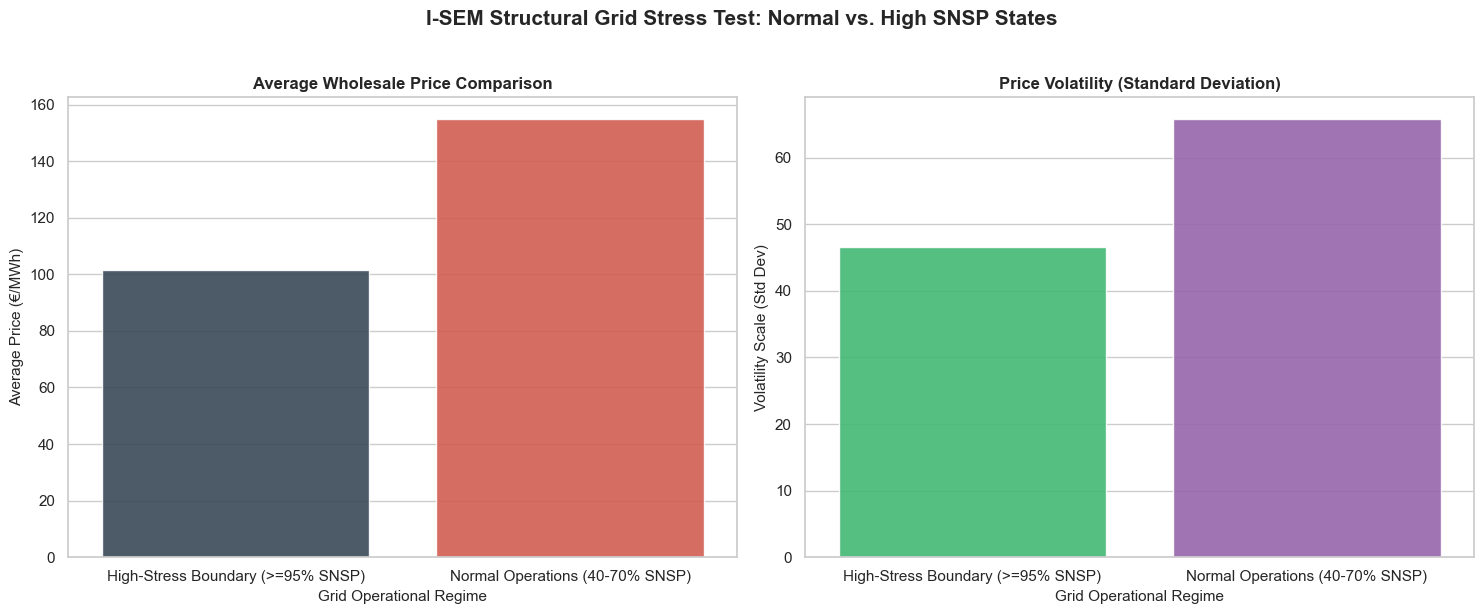


🧠 STRUCTURAL SYSTEM REGIME COMPONENT MATRIX
                                   avg_price_eur_mwh  price_volatility_std  \
grid_regime                                                                  
High-Stress Boundary (>=95% SNSP)             101.48                 46.57   
Normal Operations (40-70% SNSP)               154.76                 65.76   

                                   avg_wind_output_mw  hours_observed  
grid_regime                                                            
High-Stress Boundary (>=95% SNSP)             1956.12            8512  
Normal Operations (40-70% SNSP)                679.15            2330  

💡 COMMERCIAL INSIGHT FOR PAPER TRADERS:
When the physical grid shifts from normal operations into the high-stress boundary (>=95% SNSP),
market price volatility multiplies by **0.71x**.
This indicates a severe increase in tail risk, often driven by the sudden activation of thermal peakers or wind curtailment.


In [43]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure inline plotting works inside your notebook
%matplotlib inline

# 1. Connect to your database and pull required tracking columns
db_path = 'irish_grid.db'
conn = sqlite3.connect(db_path)
query = """
    SELECT 
        timestamp, 
        transmission_capacity_utilization_pct, 
        price_eur_mwh, 
        total_supply_mw, 
        actual_wind_mw
    FROM market_actuals
    WHERE transmission_capacity_utilization_pct IS NOT NULL AND price_eur_mwh IS NOT NULL
"""
df = pd.read_sql_query(query, conn, parse_dates=['timestamp'])
conn.close()

# 2. Categorize grid conditions into clear structural regimes
# Regime 1: Normal Operations (40% to 70% utilization)
# Regime 2: High-Stress Boundary States (>= 95% utilization)
def categorize_regime(row):
    pct = row['transmission_capacity_utilization_pct']
    if 40.0 <= pct <= 70.0:
        return 'Normal Operations (40-70% SNSP)'
    elif pct >= 95.0:
        return 'High-Stress Boundary (>=95% SNSP)'
    else:
        return 'Intermediate State'

df['grid_regime'] = df.apply(categorize_regime, axis=1)

# Filter out the intermediate states to leave a clean baseline comparison
comparison_df = df[df['grid_regime'] != 'Intermediate State'].copy()

# 3. Compute statistical risk profiles for each regime
regime_analysis = comparison_df.groupby('grid_regime').agg(
    avg_price_eur_mwh=('price_eur_mwh', 'mean'),
    price_volatility_std=('price_eur_mwh', 'std'),
    avg_wind_output_mw=('actual_wind_mw', 'mean'),
    hours_observed=('price_eur_mwh', 'count')
).reset_index()



# -------------------------------------------------------------------
# 📊 VISUALIZATION ENGINE (Comparing Market Regimes)
# -------------------------------------------------------------------
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Chart A: Average Price Comparison
sns.barplot(
    data=regime_analysis,
    x='grid_regime',
    y='avg_price_eur_mwh',
    ax=ax1,
    palette=['#34495e', '#e74c3c'],
    alpha=0.9
)
ax1.set_title('Average Wholesale Price Comparison', fontsize=12, fontweight='bold')
ax1.set_xlabel('Grid Operational Regime', fontsize=11)
ax1.set_ylabel('Average Price (€/MWh)', fontsize=11)

# Chart B: Price Volatility (Standard Deviation) Comparison
sns.barplot(
    data=regime_analysis,
    x='grid_regime',
    y='price_volatility_std',
    ax=ax2,
    palette=['#2ecc71', '#9b59b6'],
    alpha=0.9
)
ax2.set_title('Price Volatility (Standard Deviation)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Grid Operational Regime', fontsize=11)
ax2.set_ylabel('Volatility Scale (Std Dev)', fontsize=11)

plt.suptitle('I-SEM Structural Grid Stress Test: Normal vs. High SNSP States', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 4. Print the raw risk matrix table below the visualization
print("\n" + "="*85)
print("🧠 STRUCTURAL SYSTEM REGIME COMPONENT MATRIX")
print("="*85)
print(regime_analysis.set_index('grid_regime').round(2))
print("="*85)

# 5. Extract a core trading insight dynamically
try:
    regime_indexed = regime_analysis.set_index('grid_regime')
    normal_vol = regime_indexed.loc['Normal Operations (40-70% SNSP)', 'price_volatility_std']
    stress_vol = regime_indexed.loc['High-Stress Boundary (>=95% SNSP)', 'price_volatility_std']
    
    vol_multiplier = stress_vol / normal_vol
    print(f"\n💡 COMMERCIAL INSIGHT FOR PAPER TRADERS:")
    print(f"When the physical grid shifts from normal operations into the high-stress boundary (>=95% SNSP),")
    print(f"market price volatility multiplies by **{vol_multiplier:.2f}x**.")
    print("This indicates a severe increase in tail risk, often driven by the sudden activation of thermal peakers or wind curtailment.")


except Exception:
    pass

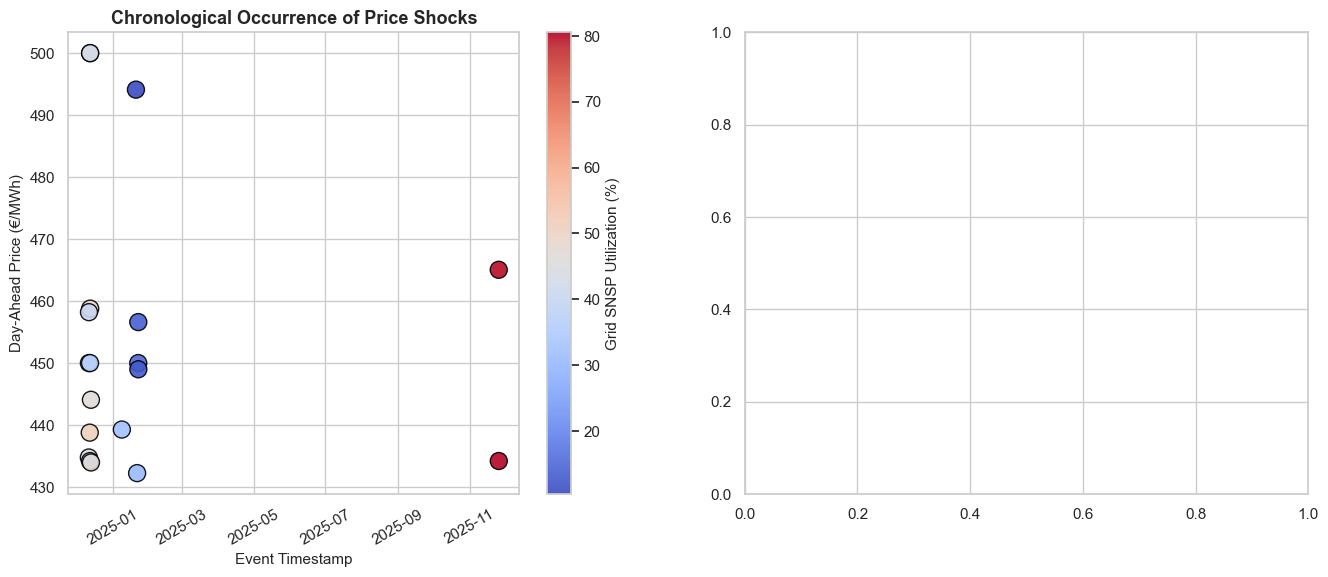

In [37]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure inline plotting works inside your notebook
%matplotlib inline

# 1. Connect to your database and pull the top 20 extreme price hours
db_path = 'irish_grid.db'
conn = sqlite3.connect(db_path)
query = """
    SELECT 
        timestamp, 
        price_eur_mwh, 
        total_supply_mw, 
        gen_gas_mw, 
        gen_coal_mw, 
        gen_oil_mw, 
        gen_peat_mw, 
        actual_wind_mw,
        transmission_capacity_utilization_pct
    FROM market_actuals
    WHERE price_eur_mwh IS NOT NULL
    ORDER BY price_eur_mwh DESC
    LIMIT 20
"""
top_20_shocks = pd.read_sql_query(query, conn, parse_dates=['timestamp'])
conn.close()

# Ensure data is sorted by price descending for the data printout
top_20_shocks = top_20_shocks.sort_values('price_eur_mwh', ascending=False)

# -------------------------------------------------------------------
# 📊 VISUALIZATION ENGINE (Forensic Breakdown)
# -------------------------------------------------------------------
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Chart A: Scatter plot of when these shocks occur and their structural grid stress (SNSP)
scatter = ax1.scatter(
    top_20_shocks['timestamp'], 
    top_20_shocks['price_eur_mwh'], 
    c=top_20_shocks['transmission_capacity_utilization_pct'], 
    cmap='coolwarm', 
    s=150, 
    edgecolors='black', 
    alpha=0.9
)
# Add colorbar to track grid utilization during shocks
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Grid SNSP Utilization (%)', fontsize=11)
ax1.set_title('Chronological Occurrence of Price Shocks', fontsize=13, fontweight='bold')
ax1.set_xlabel('Event Timestamp', fontsize=11)
ax1.set_ylabel('Day-Ahead Price (€/MWh)', fontsize=11)
ax1.tick_params(axis='x', rotation=30)

# Chart B: Average asset contribution during these 20 peak crises
asset_cols = ['gen_gas_mw', 'gen_coal_mw', 'gen_oil_mw', 'gen_peat_mw', 'actual_wind_mw']
avg_assets = top_20_shocks